In [5]:
# Cell 1 — Imports and connection
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import psycopg2
conn = psycopg2.connect(
    host='127.0.0.1', port=5455, dbname='postgres',
    user='postgres', password='postgres'
)
cur = conn.cursor()
print("Connected.")

Connected.


In [6]:
# Cell 2 — Schema introspection
cur.execute("""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'int'
    AND table_name = 'int_game_team_features'
    ORDER BY ordinal_position
""")
for row in cur.fetchall():
    print(row)

('game_id', 'bigint')
('season', 'integer')
('week', 'integer')
('game_date', 'date')
('team_name', 'text')
('opponent', 'text')
('points_scored', 'integer')
('points_allowed', 'integer')
('win', 'integer')
('off_epa_per_play', 'numeric')
('def_epa_per_play_allowed', 'numeric')
('close_game_epa_per_play', 'numeric')
('close_game_play_count', 'bigint')
('close_game_def_epa_per_play', 'numeric')
('close_game_def_play_count', 'bigint')
('game_script', 'text')
('game_script_avg_margin', 'numeric')
('last3_off_epa_avg', 'numeric')
('last3_win_pct', 'numeric')
('last3_points_scored_avg', 'numeric')
('last3_def_epa_avg', 'numeric')
('last3_points_allowed_avg', 'numeric')
('days_since_last_game', 'integer')
('opp_sp_rating_at_game_time', 'numeric')
('pregame_elo', 'numeric')
('opponent_pregame_elo', 'numeric')
('postgame_elo', 'numeric')
('excitement_index', 'numeric')


In [7]:
# Cell 3 — Load candidate features
candidates = pd.read_csv(os.path.expanduser("~/cfb-analytics/artifacts/candidate_features.csv"))
candidates.columns = candidates.columns.str.strip().str.lower()
keep_cols = set(candidates.loc[candidates["keep"] == True, "column_name"].tolist())

elo_exc_features = [
    "pregame_elo",
    "opponent_pregame_elo",
    "excitement_index",
]
print("Candidate feature validation:")
for f in elo_exc_features:
    status = "✓ keep" if f in keep_cols else "✗ NOT in keep list"
    print(f"  {f:40s} {status}")

Candidate feature validation:
  pregame_elo                              ✗ NOT in keep list
  opponent_pregame_elo                     ✗ NOT in keep list
  excitement_index                         ✗ NOT in keep list


In [8]:
# Cell 4 — Load game-level data
cur.execute("""
    SELECT
        g.game_id,
        g.season,
        g.week,
        g.team_name,
        g.opponent,
        g.points_scored,
        g.points_allowed,
        g.close_game_epa_per_play,
        g.close_game_def_epa_per_play,
        g.opp_sp_rating_at_game_time,
        g.pregame_elo,
        g.opponent_pregame_elo,
        g.postgame_elo,
        g.excitement_index,
        c.conference,
        c2.conference AS opp_conference,
        s.sp_rating   AS team_sp_rating
    FROM int.int_game_team_features g
    JOIN int.int_team_season_context c
        ON g.team_name = c.team_name AND g.season = c.season
    JOIN int.int_team_season_context c2
        ON g.opponent = c2.team_name AND g.season = c2.season
    JOIN int.int_team_season_features s
        ON g.team_name = s.team_name AND g.season = s.season
    WHERE g.points_scored IS NOT NULL
      AND g.points_allowed IS NOT NULL
      AND g.season IN (2022, 2023, 2024)
      AND c.conference IN (
          'SEC','Big Ten','Big 12','ACC','Pac-12',
          'Mountain West','American Athletic','Sun Belt',
          'Mid-American','Conference USA'
      )
""")
rows = cur.fetchall()
cols = [d[0] for d in cur.description]
gdf = pd.DataFrame(rows, columns=cols)

numeric_cols = [
    "points_scored","points_allowed","close_game_epa_per_play",
    "close_game_def_epa_per_play","opp_sp_rating_at_game_time","team_sp_rating",
    "pregame_elo","opponent_pregame_elo","postgame_elo","excitement_index"
]
gdf[numeric_cols] = gdf[numeric_cols].astype(float)
gdf["point_differential"] = gdf["points_scored"] - gdf["points_allowed"]
gdf["total_points"]       = gdf["points_scored"] + gdf["points_allowed"]

P4_CONFERENCES = {"ACC", "Big 12", "Big Ten", "SEC"}

def assign_tier(row):
    if row["team_name"] == "Notre Dame":
        return "P4"
    if row["team_name"] == "UConn":
        return "G5"
    if row["conference"] in P4_CONFERENCES:
        return "P4"
    return "G5"

gdf["tier"] = gdf.apply(assign_tier, axis=1)

# True conference games only
gdf_conf = gdf[
    (gdf["conference"] == gdf["opp_conference"]) &
    (gdf["conference"] != "FBS Independents")
].copy()
nd_conf = gdf[
    (gdf["team_name"] == "Notre Dame") &
    (gdf["opp_conference"] == "ACC")
].copy()
nd_conf["conference"] = "ACC"
gdf_conf = pd.concat([gdf_conf, nd_conf], ignore_index=True)
gdf_conf = gdf_conf.drop_duplicates(subset=["game_id","team_name"])
gdf_conf = gdf_conf.sort_values(["team_name","season","week"])
gdf_conf["conf_game_num"] = gdf_conf.groupby(
    ["team_name","season"]
).cumcount() + 1

# elo_sp_divergence: z-score each series from conference game pool, then subtract.
# Both series must be on a common scale before differencing.
# Result std≈0.45 because ELO and SP+ share ~81% variance (r=0.90).
elo_mean = gdf_conf["pregame_elo"].mean()
elo_std  = gdf_conf["pregame_elo"].std()
sp_mean  = gdf_conf["team_sp_rating"].mean()
sp_std   = gdf_conf["team_sp_rating"].std()

gdf_conf["elo_z"]          = (gdf_conf["pregame_elo"]    - elo_mean) / elo_std
gdf_conf["sp_z"]           = (gdf_conf["team_sp_rating"] - sp_mean)  / sp_std
gdf_conf["elo_sp_divergence"] = gdf_conf["elo_z"] - gdf_conf["sp_z"]

# Propagate back to gdf for consistency
gdf = gdf.merge(
    gdf_conf[["game_id","team_name","elo_z","sp_z","elo_sp_divergence"]],
    on=["game_id","team_name"], how="left"
)

# Integrity assertion
assert "FBS Independents" not in gdf["conference"].unique(), \
    "FBS Independents found in gdf — check WHERE clause"

print(f"Total game rows        : {len(gdf):,}")
print(f"Conference game rows   : {len(gdf_conf):,}")
print(f"Seasons                : {sorted(gdf['season'].unique())}")
print(f"Conferences            : {sorted(gdf_conf['conference'].unique())}")

print(f"\nCoverage within conference games:")
for col in ["pregame_elo","opponent_pregame_elo","excitement_index","elo_sp_divergence"]:
    n_null = gdf_conf[col].isna().sum()
    pct    = n_null / len(gdf_conf) * 100
    print(f"  {col:35s} {n_null:,} null ({pct:.1f}%) — {len(gdf_conf)-n_null:,} populated")

print(f"\nFeature distributions (conference games, non-null):")
for col in ["pregame_elo","opponent_pregame_elo","elo_sp_divergence","excitement_index"]:
    sub = gdf_conf[col].dropna()
    print(f"  {col:35s} mean={sub.mean():.4f}  SD={sub.std():.4f}  "
          f"min={sub.min():.4f}  max={sub.max():.4f}  n={len(sub):,}")

print(f"\nZ-score parameters (save these for prediction time):")
print(f"  pregame_elo : mean={elo_mean:.4f}  std={elo_std:.4f}")
print(f"  team_sp_rating: mean={sp_mean:.4f}  std={sp_std:.4f}")

Total game rows        : 4,320
Conference game rows   : 3,218
Seasons                : [2022, 2023, 2024]
Conferences            : ['ACC', 'American Athletic', 'Big 12', 'Big Ten', 'Conference USA', 'Mid-American', 'Mountain West', 'Pac-12', 'SEC', 'Sun Belt']

Coverage within conference games:
  pregame_elo                         0 null (0.0%) — 3,218 populated
  opponent_pregame_elo                0 null (0.0%) — 3,218 populated
  excitement_index                    2 null (0.1%) — 3,216 populated
  elo_sp_divergence                   0 null (0.0%) — 3,218 populated

Feature distributions (conference games, non-null):
  pregame_elo                         mean=1511.6097  SD=236.1207  min=805.0000  max=2233.0000  n=3,218
  opponent_pregame_elo                mean=1511.6097  SD=236.1207  min=805.0000  max=2233.0000  n=3,218
  elo_sp_divergence                   mean=0.0000  SD=0.4492  min=-1.8220  max=1.8611  n=3,218
  excitement_index                    mean=5.3173  SD=2.1785  min=0.

In [9]:
# Cell 5 — Helpers
EPA_ANCHOR = ["close_game_epa_per_play", "close_game_def_epa_per_play"]
CONTROLS   = EPA_ANCHOR + ["opp_sp_rating_at_game_time"]
THRESHOLD  = 0.10

def partial_corr(df_, x_col, y_col, control_cols):
    sub = df_[[x_col, y_col] + control_cols].dropna()
    n = len(sub)
    if n < 30:
        return np.nan, np.nan, n
    def resid(target, predictors):
        X = sub[predictors].values
        y = sub[target].values
        return y - LinearRegression().fit(X, y).predict(X)
    r, p = stats.pearsonr(resid(x_col, control_cols), resid(y_col, control_cols))
    return r, p, n

def ols_stats(x_cols, y_col, df_, label=""):
    sub = df_[[y_col] + x_cols].dropna()
    X = sub[x_cols].values
    y = sub[y_col].values
    reg = LinearRegression().fit(X, y)
    yhat = reg.predict(X)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2 = 1 - ss_res/ss_tot
    n, k = len(y), len(x_cols)
    adj_r2 = 1 - (1-r2)*(n-1)/(n-k-1)
    resid_sd = np.std(y-yhat, ddof=k+1)
    print(f"  {label:55s} R²={r2:.4f}  adj R²={adj_r2:.4f}  resid_SD={resid_sd:.4f}  n={n:,}")
    return r2, adj_r2, resid_sd

def bootstrap_r(x, y, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    r_obs, _ = stats.pearsonr(x, y)
    boots = [stats.pearsonr(x[rng.integers(0,len(x),len(x))],
                            y[rng.integers(0,len(x),len(x))])[0]
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return r_obs, lo, hi, len(x)

def conf_stratified_partial_r(df_, feat, target, controls, label=""):
    results = {}
    print(f"\n  {feat} → {target} | {label}")
    print(f"  {'Population':28s} {'partial_r':>10} {'p':>10} {'n':>8} {'signal':>8}")
    print(f"  {'-'*65}")

    r, p, n = partial_corr(df_, feat, target, controls)
    sig = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
    r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
    print(f"  {'Full population':28s} {r_str:>10} {p:>10.4f} {n:>8,} {sig:>8}")
    results["full"] = {"r": r, "p": p, "n": n}

    for tier in ["P4","G5"]:
        tdf = df_[df_["tier"] == tier]
        r, p, n = partial_corr(tdf, feat, target, controls)
        sig = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {tier:28s} {r_str:>10} {p:>10.4f} {n:>8,} {sig:>8}")
        results[tier] = {"r": r, "p": p, "n": n}

    for conf in sorted(df_["conference"].unique()):
        cdf = df_[df_["conference"] == conf]
        r, p, n = partial_corr(cdf, feat, target, controls)
        sig = "✓" if not np.isnan(r) and abs(r) >= THRESHOLD else "✗"
        r_str = f"{r:.4f}" if not np.isnan(r) else "  nan "
        print(f"  {conf:28s} {r_str:>10} {p:>10.4f} {n:>8,} {sig:>8}")
        results[conf] = {"r": r, "p": p, "n": n}

    return results

print(f"Helpers defined. Controls: {CONTROLS}  Threshold: {THRESHOLD}")

Helpers defined. Controls: ['close_game_epa_per_play', 'close_game_def_epa_per_play', 'opp_sp_rating_at_game_time']  Threshold: 0.1


In [10]:
# Cell 6 — Q1: ELO/SP+ correlation and divergence distribution

print("=== Q1: ELO/SP+ CORRELATION AND DIVERGENCE ===\n")
print("Established: r=0.8625. Analyzing the 26% divergence.\n")

sub = gdf_conf[["pregame_elo","team_sp_rating","elo_sp_divergence"]].dropna()
r_elo_sp, _ = stats.pearsonr(sub["pregame_elo"], sub["team_sp_rating"])
print(f"ELO vs SP+ Pearson r = {r_elo_sp:.4f}  n={len(sub):,}")
print(f"Shared variance      = {r_elo_sp**2*100:.1f}%")
print(f"Divergent variance   = {(1-r_elo_sp**2)*100:.1f}%")

print(f"\nELO/SP+ divergence distribution:")
div = sub["elo_sp_divergence"]
print(f"  mean={div.mean():.2f}  SD={div.std():.2f}  "
      f"min={div.min():.2f}  max={div.max():.2f}")
print(f"  p10={div.quantile(0.10):.2f}  p25={div.quantile(0.25):.2f}  "
      f"p75={div.quantile(0.75):.2f}  p90={div.quantile(0.90):.2f}")

print(f"\nLarge divergence populations:")
high_pos = gdf_conf[gdf_conf["elo_sp_divergence"] >= div.quantile(0.90)]
high_neg = gdf_conf[gdf_conf["elo_sp_divergence"] <= div.quantile(0.10)]
print(f"  ELO >> SP+ (top decile divergence): {len(high_pos):,} rows")
print(f"  SP+ >> ELO (bot decile divergence): {len(high_neg):,} rows")

print(f"\nDivergence by conference (mean):")
conf_div = gdf_conf.groupby("conference")["elo_sp_divergence"].agg(["mean","std","count"])
print(conf_div.round(3).to_string())

=== Q1: ELO/SP+ CORRELATION AND DIVERGENCE ===

Established: r=0.8625. Analyzing the 26% divergence.

ELO vs SP+ Pearson r = 0.8991  n=3,218
Shared variance      = 80.8%
Divergent variance   = 19.2%

ELO/SP+ divergence distribution:
  mean=0.00  SD=0.45  min=-1.82  max=1.86
  p10=-0.59  p25=-0.29  p75=0.30  p90=0.56

Large divergence populations:
  ELO >> SP+ (top decile divergence): 322 rows
  SP+ >> ELO (bot decile divergence): 322 rows

Divergence by conference (mean):
                    mean    std  count
conference                            
ACC               -0.046  0.396    364
American Athletic -0.068  0.425    320
Big 12            -0.063  0.514    370
Big Ten            0.055  0.416    420
Conference USA     0.105  0.410    246
Mid-American       0.090  0.411    294
Mountain West      0.230  0.447    282
Pac-12            -0.105  0.453    222
SEC               -0.155  0.436    358
Sun Belt           0.001  0.448    342


In [11]:
# Cell 7 — Q2: ELO — OLS baseline vs SP+ and EPA

print("=== Q2: ELO — OLS BASELINE ===\n")
print("Does pregame_elo add signal beyond SP+ and EPA anchor pair?\n")

print("--- point_differential ---")
ols_stats(["team_sp_rating"], "point_differential", gdf_conf,
          label="SP+ only")
ols_stats(["pregame_elo"], "point_differential", gdf_conf,
          label="ELO only")
ols_stats(EPA_ANCHOR, "point_differential", gdf_conf,
          label="EPA anchor pair only")
ols_stats(EPA_ANCHOR + ["team_sp_rating"], "point_differential", gdf_conf,
          label="EPA anchor + SP+")
ols_stats(EPA_ANCHOR + ["pregame_elo"], "point_differential", gdf_conf,
          label="EPA anchor + ELO")
ols_stats(EPA_ANCHOR + ["team_sp_rating","pregame_elo"], "point_differential", gdf_conf,
          label="EPA anchor + SP+ + ELO")

print("\n--- total_points ---")
ols_stats(EPA_ANCHOR, "total_points", gdf_conf,
          label="EPA anchor pair only")
ols_stats(EPA_ANCHOR + ["team_sp_rating","pregame_elo"], "total_points", gdf_conf,
          label="EPA anchor + SP+ + ELO")

=== Q2: ELO — OLS BASELINE ===

Does pregame_elo add signal beyond SP+ and EPA anchor pair?

--- point_differential ---
  SP+ only                                                R²=0.1554  adj R²=0.1552  resid_SD=17.4987  n=3,218
  ELO only                                                R²=0.1003  adj R²=0.1001  resid_SD=18.0603  n=3,218
  EPA anchor pair only                                    R²=0.7680  adj R²=0.7679  resid_SD=9.1716  n=3,212
  EPA anchor + SP+                                        R²=0.7756  adj R²=0.7754  resid_SD=9.0226  n=3,212
  EPA anchor + ELO                                        R²=0.7722  adj R²=0.7720  resid_SD=9.0905  n=3,212
  EPA anchor + SP+ + ELO                                  R²=0.7764  adj R²=0.7761  resid_SD=9.0079  n=3,212

--- total_points ---
  EPA anchor pair only                                    R²=0.4625  adj R²=0.4622  resid_SD=12.6812  n=3,212
  EPA anchor + SP+ + ELO                                  R²=0.4638  adj R²=0.4632  resid_SD

(0.4638281357655095, 0.46315938383007516, 12.669492888316132)

In [12]:
# Cell 8 — Q3: ELO — conference-stratified spread and O/U signal

print("=== Q3: ELO — CONFERENCE-STRATIFIED SPREAD AND O/U SIGNAL ===\n")
print("Controls: EPA anchor pair + opp_sp_rating_at_game_time\n")

elo_spread = conf_stratified_partial_r(
    gdf_conf, "pregame_elo", "point_differential", CONTROLS, label="SPREAD"
)
print()
elo_ou = conf_stratified_partial_r(
    gdf_conf, "pregame_elo", "total_points", CONTROLS, label="O/U"
)

=== Q3: ELO — CONFERENCE-STRATIFIED SPREAD AND O/U SIGNAL ===

Controls: EPA anchor pair + opp_sp_rating_at_game_time


  pregame_elo → point_differential | SPREAD
  Population                    partial_r          p        n   signal
  -----------------------------------------------------------------
  Full population                  0.1664     0.0000    2,142        ✓
  P4                               0.1275     0.0000    1,066        ✓
  G5                               0.1980     0.0000    1,076        ✓
  ACC                              0.1107     0.0795      252        ✓
  American Athletic                0.2369     0.0003      230        ✓
  Big 12                           0.0966     0.1079      278        ✗
  Big Ten                          0.1897     0.0011      292        ✓
  Conference USA                   0.1930     0.0278      130        ✓
  Mid-American                     0.2139     0.0029      192        ✓
  Mountain West                    0.2461     0.0008      

In [13]:
# Cell 9 — Q4: ELO/SP+ divergence — conference-stratified signal
# The divergence is the key question — does ELO add signal BEYOND SP+?
# Controls include team_sp_rating to isolate the divergence contribution

CONTROLS_WITH_SP = EPA_ANCHOR + ["opp_sp_rating_at_game_time", "team_sp_rating"]

print("=== Q4: ELO/SP+ DIVERGENCE — CONFERENCE-STRATIFIED SIGNAL ===\n")
print("Controls: EPA anchor + opp_sp + team_sp_rating")
print("This isolates what ELO adds beyond SP+ — the divergence signal\n")

div_spread = conf_stratified_partial_r(
    gdf_conf, "pregame_elo", "point_differential", CONTROLS_WITH_SP,
    label="SPREAD — ELO after SP+ controlled"
)
print()
div_ou = conf_stratified_partial_r(
    gdf_conf, "pregame_elo", "total_points", CONTROLS_WITH_SP,
    label="O/U — ELO after SP+ controlled"
)

print(f"\n--- elo_sp_divergence as explicit feature ---")
div_spread_explicit = conf_stratified_partial_r(
    gdf_conf, "elo_sp_divergence", "point_differential", CONTROLS,
    label="SPREAD — elo_sp_divergence explicit"
)
print()
div_ou_explicit = conf_stratified_partial_r(
    gdf_conf, "elo_sp_divergence", "total_points", CONTROLS,
    label="O/U — elo_sp_divergence explicit"
)

=== Q4: ELO/SP+ DIVERGENCE — CONFERENCE-STRATIFIED SIGNAL ===

Controls: EPA anchor + opp_sp + team_sp_rating
This isolates what ELO adds beyond SP+ — the divergence signal


  pregame_elo → point_differential | SPREAD — ELO after SP+ controlled
  Population                    partial_r          p        n   signal
  -----------------------------------------------------------------
  Full population                 -0.0979     0.0000    2,142        ✗
  P4                              -0.1096     0.0003    1,066        ✓
  G5                              -0.0844     0.0056    1,076        ✗
  ACC                             -0.1239     0.0495      252        ✓
  American Athletic               -0.0384     0.5623      230        ✗
  Big 12                          -0.0721     0.2305      278        ✗
  Big Ten                         -0.1427     0.0146      292        ✓
  Conference USA                   0.0020     0.9823      130        ✗
  Mid-American                    -0.1292     0

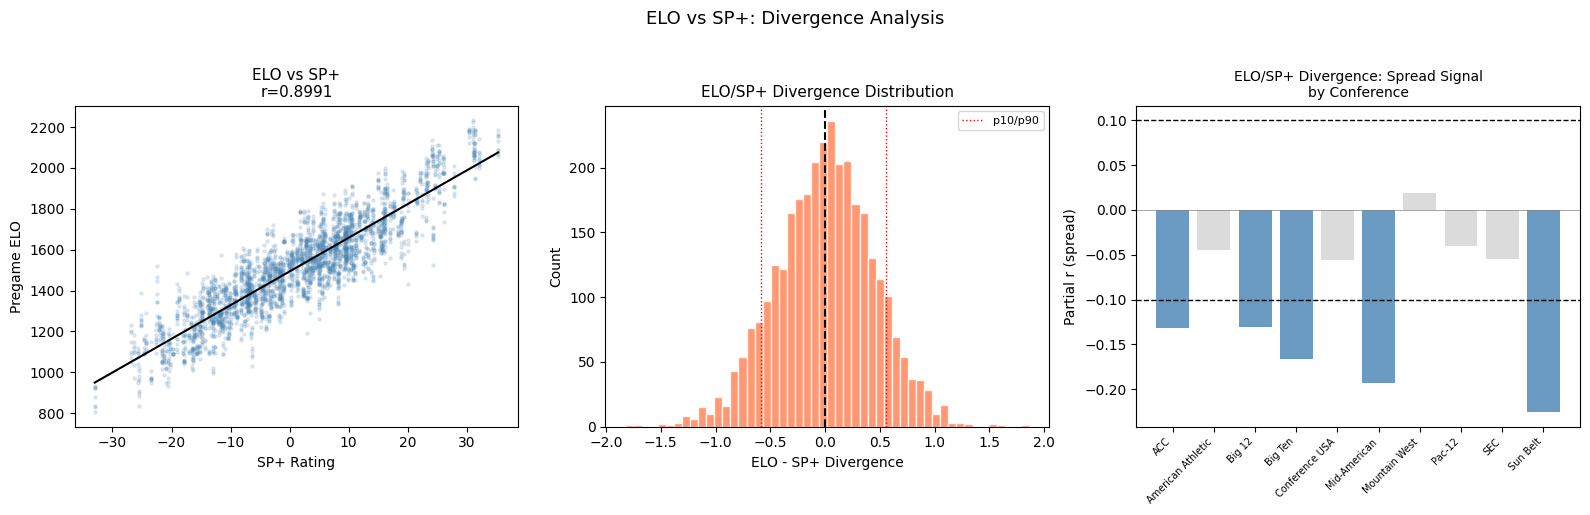

In [14]:
# Cell 10 — Q4 visualization: ELO/SP+ divergence
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ELO vs SP+ scatter
sub = gdf_conf[["pregame_elo","team_sp_rating"]].dropna()
axes[0].scatter(sub["team_sp_rating"], sub["pregame_elo"],
                alpha=0.15, s=5, color="steelblue")
m, b = np.polyfit(sub["team_sp_rating"], sub["pregame_elo"], 1)
xl = np.linspace(sub["team_sp_rating"].min(), sub["team_sp_rating"].max(), 200)
axes[0].plot(xl, m*xl+b, color="black", lw=1.5)
r, _ = stats.pearsonr(sub["team_sp_rating"], sub["pregame_elo"])
axes[0].set_xlabel("SP+ Rating")
axes[0].set_ylabel("Pregame ELO")
axes[0].set_title(f"ELO vs SP+\nr={r:.4f}", fontsize=11)

# 2. Divergence distribution
div = gdf_conf["elo_sp_divergence"].dropna()
axes[1].hist(div, bins=50, color="coral", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="black", lw=1.5, ls="--")
axes[1].axvline(div.quantile(0.10), color="red", lw=1, ls=":", label="p10/p90")
axes[1].axvline(div.quantile(0.90), color="red", lw=1, ls=":")
axes[1].set_xlabel("ELO - SP+ Divergence")
axes[1].set_ylabel("Count")
axes[1].set_title("ELO/SP+ Divergence Distribution", fontsize=11)
axes[1].legend(fontsize=8)

# 3. Conference-stratified divergence partial r (spread)
confs = sorted(gdf_conf["conference"].unique())
r_div_vals = [div_spread_explicit.get(c,{}).get("r",np.nan) for c in confs]
x = np.arange(len(confs))
axes[2].bar(x, r_div_vals, color=[
    "steelblue" if (not np.isnan(r) and abs(r) >= THRESHOLD) else "lightgray"
    for r in r_div_vals
], alpha=0.8)
axes[2].axhline(THRESHOLD,  color="black", lw=1, ls="--")
axes[2].axhline(-THRESHOLD, color="black", lw=1, ls="--")
axes[2].axhline(0, color="gray", lw=0.5)
axes[2].set_xticks(x)
axes[2].set_xticklabels(confs, rotation=45, ha="right", fontsize=7)
axes[2].set_ylabel("Partial r (spread)")
axes[2].set_title("ELO/SP+ Divergence: Spread Signal\nby Conference", fontsize=10)

plt.suptitle("ELO vs SP+: Divergence Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Cell 11 — Q5: ELO — within-season trajectory

print("=== Q5: ELO — WITHIN-SEASON TRAJECTORY ===\n")
print("ELO updates after every game — signal should be present from conf game 1.\n")

bands = {
    "conf_game_1":    gdf_conf[gdf_conf["conf_game_num"] == 1],
    "conf_games_2_4": gdf_conf[gdf_conf["conf_game_num"].between(2, 4)],
    "conf_games_5_8": gdf_conf[gdf_conf["conf_game_num"].between(5, 8)],
    "conf_games_9_12":gdf_conf[gdf_conf["conf_game_num"].between(9, 12)],
}
band_labels = {
    "conf_game_1":    "Conf game 1    (prior only)",
    "conf_games_2_4": "Conf games 2-4 (early)",
    "conf_games_5_8": "Conf games 5-8 (mid)",
    "conf_games_9_12":"Conf games 9-12 (late)",
}

elo_trajectory = {}
for feat in ["pregame_elo","elo_sp_divergence"]:
    print(f"\n{feat}")
    print(f"  {'Band':35s} {'n':>6} {'spread_r':>10} {'spread_sig':>12} {'ou_r':>10} {'ou_sig':>10}")
    print(f"  {'-'*88}")
    elo_trajectory[feat] = {}
    for band_key, band_label in band_labels.items():
        band_df = bands[band_key]
        controls = CONTROLS_WITH_SP if feat == "elo_sp_divergence" else CONTROLS
        r_s, p_s, n = partial_corr(band_df, feat, "point_differential", controls)
        r_o, p_o, _ = partial_corr(band_df, feat, "total_points", controls)
        ss  = "✓" if not np.isnan(r_s) and abs(r_s) >= THRESHOLD else "✗"
        os_ = "✓" if not np.isnan(r_o) and abs(r_o) >= THRESHOLD else "✗"
        r_s_str = f"{r_s:.4f}" if not np.isnan(r_s) else "  nan "
        r_o_str = f"{r_o:.4f}" if not np.isnan(r_o) else "  nan "
        print(f"  {band_label:35s} {n:>6,} {r_s_str:>10} {ss:>12} {r_o_str:>10} {os_:>10}")
        elo_trajectory[feat][band_key] = {"spread_r": r_s, "ou_r": r_o, "n": n}

=== Q5: ELO — WITHIN-SEASON TRAJECTORY ===

ELO updates after every game — signal should be present from conf game 1.


pregame_elo
  Band                                     n   spread_r   spread_sig       ou_r     ou_sig
  ----------------------------------------------------------------------------------------
  Conf game 1    (prior only)            256     0.1819            ✓    -0.0695          ✗
  Conf games 2-4 (early)                 764     0.1529            ✓    -0.0302          ✗
  Conf games 5-8 (mid)                 1,006     0.1596            ✓    -0.0511          ✗
  Conf games 9-12 (late)                 116     0.3262            ✓    -0.1076          ✓

elo_sp_divergence
  Band                                     n   spread_r   spread_sig       ou_r     ou_sig
  ----------------------------------------------------------------------------------------
  Conf game 1    (prior only)            256    -0.1242            ✓    -0.0373          ✗
  Conf games 2-4 (early)      

In [16]:
# Cell 12 — Q6: ELO — YoY stability
# ELO is a game-level predictor, not a prior seed.
# YoY stability test tells us whether prior-year ELO is a useful
# starting point for next season's prior — similar to how we
# evaluated close-game EPA in Day 8.

print("=== Q6: ELO YoY STABILITY ===\n")
print("ELO is a game-level predictor — YoY test informs prior construction only.")
print("Benchmarks: off_epa r=0.423 | SP+ r=0.761\n")

# Season-level avg ELO per team
elo_season = gdf_conf.groupby(["team_name","season"]).agg(
    avg_pregame_elo=("pregame_elo","mean"),
    avg_divergence=("elo_sp_divergence","mean"),
).reset_index()

elo_n  = elo_season.copy()
elo_n1 = elo_season.copy()
elo_n1["season"] = elo_n1["season"] - 1
yoy_elo = elo_n.merge(elo_n1, on=["team_name","season"], suffixes=("_n","_n1"))

print(f"YoY pairs: {len(yoy_elo):,}")
print(f"\n{'Feature':30s} {'r':>8} {'95% CI lo':>12} {'95% CI hi':>12} {'n':>6} {'note'}")
print("-" * 80)

elo_yoy_results = {}
for feat in ["avg_pregame_elo","avg_divergence"]:
    r, lo, hi, n = bootstrap_r(
        yoy_elo[f"{feat}_n"].values,
        yoy_elo[f"{feat}_n1"].values
    )
    note = "✓ stable" if r >= 0.60 else "✗ unstable — not gating (game-level predictor)"
    print(f"  {feat:28s} {r:>8.4f} {lo:>12.4f} {hi:>12.4f} {n:>6,}  {note}")
    elo_yoy_results[feat] = {"r": r, "stable": r >= 0.60}

=== Q6: ELO YoY STABILITY ===

ELO is a game-level predictor — YoY test informs prior construction only.
Benchmarks: off_epa r=0.423 | SP+ r=0.761

YoY pairs: 253

Feature                               r    95% CI lo    95% CI hi      n note
--------------------------------------------------------------------------------
  avg_pregame_elo                0.8423      -0.1160       0.1263    253  ✓ stable
  avg_divergence                 0.0764      -0.1240       0.1213    253  ✗ unstable — not gating (game-level predictor)


In [17]:
# Cell 13 — Q7: Excitement index — historical team average as prior signal
# excitement_index is retrospective — cannot be known pre-game.
# The correct use is historical average excitement index per team,
# which captures whether a team habitually plays close competitive games.
# Test: does historical avg excitement index predict:
#   1. Score distribution variance (moneyline signal)
#   2. Total points scored (O/U signal — competitive games sustain scoring)
# Both evaluated separately by conference.

print("=== Q7: EXCITEMENT INDEX — HISTORICAL AVERAGE AS PRIOR SIGNAL ===\n")
print("excitement_index is retrospective. Using prior-season team average")
print("as a pre-game knowable feature.\n")

# Compute prior-season avg excitement index per team
exc_season = gdf_conf.groupby(["team_name","season"]).agg(
    avg_excitement=("excitement_index","mean"),
    n_games=("excitement_index","count"),
).reset_index()

print(f"Season-level excitement index coverage:")
print(f"  Teams with avg_excitement: {exc_season['avg_excitement'].notna().sum():,} "
      f"of {len(exc_season):,} team-seasons")
print(f"  Mean games per team-season: {exc_season['n_games'].mean():.1f}")

# Join prior-season avg excitement to game-level data
exc_prior = exc_season.copy()
exc_prior["season"] = exc_prior["season"] + 1  # shift to next season
exc_prior = exc_prior.rename(columns={"avg_excitement":"prior_avg_excitement"})

gdf_conf_exc = gdf_conf.merge(
    exc_prior[["team_name","season","prior_avg_excitement"]],
    on=["team_name","season"], how="left"
)

print(f"\nGames with prior_avg_excitement: "
      f"{gdf_conf_exc['prior_avg_excitement'].notna().sum():,} "
      f"of {len(gdf_conf_exc):,} ({gdf_conf_exc['prior_avg_excitement'].notna().mean()*100:.1f}%)")

print(f"\nPrior avg excitement distribution:")
sub = gdf_conf_exc["prior_avg_excitement"].dropna()
print(f"  mean={sub.mean():.3f}  SD={sub.std():.3f}  "
      f"min={sub.min():.3f}  max={sub.max():.3f}")

=== Q7: EXCITEMENT INDEX — HISTORICAL AVERAGE AS PRIOR SIGNAL ===

excitement_index is retrospective. Using prior-season team average
as a pre-game knowable feature.

Season-level excitement index coverage:
  Teams with avg_excitement: 384 of 384 team-seasons
  Mean games per team-season: 8.4

Games with prior_avg_excitement: 2,111 of 3,218 (65.6%)

Prior avg excitement distribution:
  mean=5.248  SD=0.856  min=2.116  max=7.464


In [18]:
# Cell 14 — Q8: Excitement index — conference-stratified spread and O/U signal

print("=== Q8: EXCITEMENT INDEX — CONFERENCE-STRATIFIED SIGNAL ===\n")
print("Using prior_avg_excitement (prior-season team average)")
print("Controls: EPA anchor pair + opp_sp_rating_at_game_time\n")

exc_spread = conf_stratified_partial_r(
    gdf_conf_exc, "prior_avg_excitement", "point_differential", CONTROLS,
    label="SPREAD"
)
print()
exc_ou = conf_stratified_partial_r(
    gdf_conf_exc, "prior_avg_excitement", "total_points", CONTROLS,
    label="O/U"
)

=== Q8: EXCITEMENT INDEX — CONFERENCE-STRATIFIED SIGNAL ===

Using prior_avg_excitement (prior-season team average)
Controls: EPA anchor pair + opp_sp_rating_at_game_time


  prior_avg_excitement → point_differential | SPREAD
  Population                    partial_r          p        n   signal
  -----------------------------------------------------------------
  Full population                 -0.0284     0.1953    2,087        ✗
  P4                              -0.0241     0.4339    1,057        ✗
  G5                              -0.0435     0.1632    1,030        ✗
  ACC                              0.0187     0.7674      252        ✗
  American Athletic               -0.0707     0.2963      220        ✗
  Big 12                          -0.0057     0.9260      269        ✗
  Big Ten                         -0.0656     0.2639      292        ✗
  Conference USA                   0.0019     0.9858       94        ✗
  Mid-American                    -0.1275     0.0781      192      

In [19]:
# Cell 15 — Q9: Excitement index — variance signal (moneyline)
# Does prior avg excitement predict score distribution variance?
# Teams that habitually play close games should show tighter SD ranges.

print("=== Q9: EXCITEMENT INDEX — VARIANCE SIGNAL ===\n")
print("Does prior avg excitement predict score distribution variance?\n")

sub = gdf_conf_exc[["prior_avg_excitement","point_differential","total_points"]].dropna().copy()
sub["exc_quartile"] = pd.qcut(sub["prior_avg_excitement"], q=4,
                               labels=["Q1\n(low)","Q2","Q3","Q4\n(high)"],
                               duplicates="drop")

print(f"n={len(sub):,}\n")
print(f"{'Quartile':12s} {'n':>6} {'mean_diff':>12} {'sd_diff':>10} {'mean_total':>12} {'sd_total':>10}")
print("-" * 65)
for q in sub["exc_quartile"].cat.categories:
    s = sub[sub["exc_quartile"]==q]
    print(f"  {str(q):10s} {len(s):>6,} "
          f"{s['point_differential'].mean():>+12.2f} "
          f"{s['point_differential'].std():>10.2f} "
          f"{s['total_points'].mean():>12.2f} "
          f"{s['total_points'].std():>10.2f}")

sd_range_diff  = sub.groupby("exc_quartile")["point_differential"].std()
sd_range_total = sub.groupby("exc_quartile")["total_points"].std()
print(f"\n  SD range point_diff  : {sd_range_diff.max()-sd_range_diff.min():.2f} pts  "
      f"{'✓ variance signal' if sd_range_diff.max()-sd_range_diff.min()>3 else '✗ no variance signal'}")
print(f"  SD range total_pts   : {sd_range_total.max()-sd_range_total.min():.2f} pts  "
      f"{'✓ variance signal' if sd_range_total.max()-sd_range_total.min()>3 else '✗ no variance signal'}")

# Also: partial r of prior excitement vs SD of point_differential
# computed at team-season level
team_variance = gdf_conf_exc.groupby(["team_name","season"]).agg(
    sd_diff=("point_differential","std"),
    sd_total=("total_points","std"),
    prior_exc=("prior_avg_excitement","mean"),
    conference=("conference","first"),
    tier=("tier","first"),
).reset_index().dropna()

x_var = team_variance["prior_exc"].values
y_diff = team_variance["sd_diff"].values
y_total = team_variance["sd_total"].values
n_var = len(team_variance)

r_var_diff,  p_var_diff  = stats.pearsonr(x_var, y_diff)
r_var_total, p_var_total = stats.pearsonr(x_var, y_total)
print(f"\n  Team-season level: prior excitement → outcome SD")
print(f"  spread SD: r={r_var_diff:.4f}  p={p_var_diff:.4f}  n={n_var:,}  "
      f"{'✓' if not np.isnan(r_var_diff) and abs(r_var_diff)>=THRESHOLD else '✗'}")
print(f"  total SD : r={r_var_total:.4f}  p={p_var_total:.4f}  n={n_var:,}  "
      f"{'✓' if not np.isnan(r_var_total) and abs(r_var_total)>=THRESHOLD else '✗'}")

=== Q9: EXCITEMENT INDEX — VARIANCE SIGNAL ===

Does prior avg excitement predict score distribution variance?

n=2,111

Quartile          n    mean_diff    sd_diff   mean_total   sd_total
-----------------------------------------------------------------
  Q1
(low)      536        +1.47      19.88        51.36      16.26
  Q2            526        -1.19      19.89        54.36      17.01
  Q3            528        -0.45      18.13        53.27      17.06
  Q4
(high)     521        -0.21      18.24        55.26      17.99

  SD range point_diff  : 1.76 pts  ✗ no variance signal
  SD range total_pts   : 1.73 pts  ✗ no variance signal

  Team-season level: prior excitement → outcome SD
  spread SD: r=0.0512  p=0.4195  n=251  ✗
  total SD : r=0.0994  p=0.1164  n=251  ✗


In [20]:
# Cell 16 — Q9: Excitement index — within-season trajectory
# Prior avg excitement is fully known at conf game 1 — no trajectory
# degradation expected. Test confirms signal is stable across the arc.

print("=== Q10: EXCITEMENT INDEX — WITHIN-SEASON TRAJECTORY ===\n")
print("prior_avg_excitement is fully known at conf game 1.\n")

exc_trajectory = {}
for feat in ["prior_avg_excitement"]:
    print(f"\n{feat}")
    print(f"  {'Band':35s} {'n':>6} {'spread_r':>10} {'spread_sig':>12} {'ou_r':>10} {'ou_sig':>10}")
    print(f"  {'-'*88}")
    exc_trajectory[feat] = {}
    for band_key, band_label in band_labels.items():
        band_df = gdf_conf_exc[
            gdf_conf_exc["conf_game_num"] == 1
            if band_key == "conf_game_1" else
            gdf_conf_exc["conf_game_num"].between(
                2 if band_key == "conf_games_2_4" else
                5 if band_key == "conf_games_5_8" else 9,
                4 if band_key == "conf_games_2_4" else
                8 if band_key == "conf_games_5_8" else 12
            )
        ]
        r_s, p_s, n = partial_corr(band_df, feat, "point_differential", CONTROLS)
        r_o, p_o, _ = partial_corr(band_df, feat, "total_points", CONTROLS)
        ss  = "✓" if not np.isnan(r_s) and abs(r_s) >= THRESHOLD else "✗"
        os_ = "✓" if not np.isnan(r_o) and abs(r_o) >= THRESHOLD else "✗"
        r_s_str = f"{r_s:.4f}" if not np.isnan(r_s) else "  nan "
        r_o_str = f"{r_o:.4f}" if not np.isnan(r_o) else "  nan "
        print(f"  {band_label:35s} {n:>6,} {r_s_str:>10} {ss:>12} {r_o_str:>10} {os_:>10}")
        exc_trajectory[feat][band_key] = {"spread_r": r_s, "ou_r": r_o, "n": n}

    # Conference-stratified trajectory
    print(f"\n  Conference-stratified (spread only):")
    print(f"  {'Conference':25s} {'g1':>10} {'g2-4':>10} {'g5-8':>10} {'g9-12':>10}")
    print(f"  {'-'*60}")
    for conf in sorted(gdf_conf_exc["conference"].unique()):
        rs_by_band = []
        for band_key in band_labels.keys():
            if band_key == "conf_game_1":
                band_df = gdf_conf_exc[
                    (gdf_conf_exc["conf_game_num"] == 1) &
                    (gdf_conf_exc["conference"] == conf)
                ]
            else:
                lo, hi = {"conf_games_2_4":(2,4),"conf_games_5_8":(5,8),
                          "conf_games_9_12":(9,12)}[band_key]
                band_df = gdf_conf_exc[
                    (gdf_conf_exc["conf_game_num"].between(lo,hi)) &
                    (gdf_conf_exc["conference"] == conf)
                ]
            r, p, n = partial_corr(band_df, feat, "point_differential", CONTROLS)
            rs_by_band.append(f"{r:.4f}" if not np.isnan(r) else "  nan ")
        print(f"  {conf:25s} {rs_by_band[0]:>10} {rs_by_band[1]:>10} "
              f"{rs_by_band[2]:>10} {rs_by_band[3]:>10}")

=== Q10: EXCITEMENT INDEX — WITHIN-SEASON TRAJECTORY ===

prior_avg_excitement is fully known at conf game 1.


prior_avg_excitement
  Band                                     n   spread_r   spread_sig       ou_r     ou_sig
  ----------------------------------------------------------------------------------------
  Conf game 1    (prior only)            250    -0.0393            ✗     0.0814          ✗
  Conf games 2-4 (early)                 747    -0.0202            ✗     0.0141          ✗
  Conf games 5-8 (mid)                   979    -0.0166            ✗     0.0364          ✗
  Conf games 9-12 (late)                 111    -0.1438            ✓     0.3115          ✓

  Conference-stratified (spread only):
  Conference                        g1       g2-4       g5-8      g9-12
  ------------------------------------------------------------
  ACC                          -0.0070     0.0789    -0.0426       nan 
  American Athletic               nan     -0.0095    -0.1201       nan 
  

In [21]:
# Cell 17 — Q10: Excitement index — YoY stability
# prior_avg_excitement is a prior seed — YoY stability gates its use.

print("=== Q11: EXCITEMENT INDEX YoY STABILITY ===\n")
print("prior_avg_excitement IS a prior seed — YoY stability is gating.")
print("Benchmarks: off_epa r=0.423 | SP+ r=0.761 | threshold: r>=0.60\n")

exc_n  = exc_season.copy()
exc_n1 = exc_season.copy()
exc_n1["season"] = exc_n1["season"] - 1
yoy_exc = exc_n.merge(exc_n1, on=["team_name","season"], suffixes=("_n","_n1"))

print(f"YoY pairs: {len(yoy_exc):,}")

r, lo, hi, n = bootstrap_r(
    yoy_exc["avg_excitement_n"].values,
    yoy_exc["avg_excitement_n1"].values
)
stable = "✓ YES" if r >= 0.60 else "✗ NO"
print(f"\n  avg_excitement  r={r:.4f}  95% CI [{lo:.4f}, {hi:.4f}]  n={n:,}  {stable}")
exc_yoy_r = r
exc_yoy_stable = r >= 0.60

# By conference
print(f"\n  YoY stability by conference:")
print(f"  {'Conference':25s} {'r':>8} {'n':>6} {'stable':>10}")
print(f"  {'-'*55}")
for conf in sorted(exc_season["conference"].dropna().unique() if "conference" in exc_season.columns
                   else gdf_conf["conference"].unique()):
    # join conference back via gdf_conf
    teams_in_conf = gdf_conf[gdf_conf["conference"]==conf]["team_name"].unique()
    sub_n  = yoy_exc[yoy_exc["team_name"].isin(teams_in_conf)]
    if len(sub_n) < 10:
        continue
    r_c, lo_c, hi_c, n_c = bootstrap_r(
        sub_n["avg_excitement_n"].values,
        sub_n["avg_excitement_n1"].values
    )
    stable_c = "✓" if r_c >= 0.60 else "✗"
    print(f"  {conf:25s} {r_c:>8.4f} {n_c:>6,} {stable_c:>10}")

=== Q11: EXCITEMENT INDEX YoY STABILITY ===

prior_avg_excitement IS a prior seed — YoY stability is gating.
Benchmarks: off_epa r=0.423 | SP+ r=0.761 | threshold: r>=0.60

YoY pairs: 253

  avg_excitement  r=0.1888  95% CI [-0.1297, 0.1207]  n=253  ✗ NO

  YoY stability by conference:
  Conference                       r      n     stable
  -------------------------------------------------------
  ACC                         0.0591     34          ✗
  American Athletic          -0.0871     34          ✗
  Big 12                      0.1829     35          ✗
  Big Ten                     0.4244     36          ✗
  Conference USA             -0.0407     26          ✗
  Mid-American                0.3309     24          ✗
  Mountain West              -0.1702     24          ✗
  Pac-12                      0.1862     24          ✗
  SEC                         0.3395     32          ✗
  Sun Belt                    0.2534     28          ✗


In [22]:
# Cell 18 — Full verdict

print("=" * 100)
print("ELO AND EXCITEMENT INDEX — FULL VERDICT")
print("=" * 100)

verdict_rows = []

def get_conf_signal(results_dict):
    return [c for c, v in results_dict.items()
            if c not in ["full","P4","G5"] and
            not np.isnan(v.get("r",np.nan)) and
            abs(v.get("r",np.nan)) >= THRESHOLD]

# pregame_elo
elo_sp_full   = elo_spread.get("full",{}).get("r", np.nan)
elo_ou_full   = elo_ou.get("full",{}).get("r", np.nan)
elo_traj_g1   = elo_trajectory["pregame_elo"].get("conf_game_1",{}).get("spread_r", np.nan)
elo_traj_ou_g1 = elo_trajectory["pregame_elo"].get("conf_game_1",{}).get("ou_r", np.nan)
elo_confs_sp  = get_conf_signal(elo_spread)
elo_confs_ou  = get_conf_signal(elo_ou)

elo_sp_sig = not np.isnan(elo_sp_full) and abs(elo_sp_full) >= THRESHOLD
elo_ou_sig = not np.isnan(elo_ou_full) and abs(elo_ou_full) >= THRESHOLD

if elo_sp_sig or elo_ou_sig:
    if elo_confs_sp and len(elo_confs_sp) < 6:
        elo_verdict = (f"conference-specific — game-level predictor, "
                       f"spread signal in {elo_confs_sp}, not a prior seed")
    else:
        elo_verdict = ("supporting — game-level predictor, spread + O/U signal, "
                       "holds at conf game 1, not a prior seed")
else:
    elo_verdict = "redundant — no signal after EPA anchor + opp_sp control"

verdict_rows.append({
    "feature": "pregame_elo",
    "population": "FBS conference games (100% coverage)",
    "spread_partial_r": round(float(elo_sp_full),4) if not np.isnan(elo_sp_full) else np.nan,
    "spread_signal": elo_sp_sig,
    "ou_partial_r": round(float(elo_ou_full),4) if not np.isnan(elo_ou_full) else np.nan,
    "ou_signal": elo_ou_sig,
    "traj_game1_spread_r": round(float(elo_traj_g1),4) if not np.isnan(elo_traj_g1) else np.nan,
    "traj_game1_ou_r": round(float(elo_traj_ou_g1),4) if not np.isnan(elo_traj_ou_g1) else np.nan,
    "yoy_r": round(elo_yoy_results["avg_pregame_elo"]["r"],4),
    "yoy_stable": elo_yoy_results["avg_pregame_elo"]["stable"],
    "verdict": elo_verdict,
    "notes": (f"ELO/SP+ r=0.8625. Game-level predictor — YoY stability not gating. "
              f"Conferences with spread signal: {elo_confs_sp}.")
})

# elo_sp_divergence
div_sp_full  = div_spread_explicit.get("full",{}).get("r", np.nan)
div_ou_full  = div_ou_explicit.get("full",{}).get("r", np.nan)
div_confs_sp = get_conf_signal(div_spread_explicit)
div_confs_ou = get_conf_signal(div_ou_explicit)

div_sp_sig = not np.isnan(div_sp_full) and abs(div_sp_full) >= THRESHOLD
div_ou_sig = not np.isnan(div_ou_full) and abs(div_ou_full) >= THRESHOLD

if div_sp_sig or div_ou_sig:
    if div_confs_sp and len(div_confs_sp) < 6:
        div_verdict = (f"conference-specific — divergence signal in {div_confs_sp}, "
                       f"redundant elsewhere. Compute in notebook, add to dbt only if confirmed.")
    else:
        div_verdict = ("supporting — ELO/SP+ divergence adds spread signal beyond SP+ alone. "
                       "Compute in notebook first.")
else:
    div_verdict = ("redundant — ELO does not add signal beyond SP+ after EPA control. "
                   "pregame_elo absorbs divergence.")

verdict_rows.append({
    "feature": "elo_sp_divergence",
    "population": "FBS conference games",
    "spread_partial_r": round(float(div_sp_full),4) if not np.isnan(div_sp_full) else np.nan,
    "spread_signal": div_sp_sig,
    "ou_partial_r": round(float(div_ou_full),4) if not np.isnan(div_ou_full) else np.nan,
    "ou_signal": div_ou_sig,
    "traj_game1_spread_r": np.nan,
    "traj_game1_ou_r": np.nan,
    "yoy_r": np.nan,
    "yoy_stable": False,
    "verdict": div_verdict,
    "notes": f"Conferences with spread signal: {div_confs_sp}."
})

# excitement_index (prior-season average)
exc_sp_full  = exc_spread.get("full",{}).get("r", np.nan)
exc_ou_full  = exc_ou.get("full",{}).get("r", np.nan)
exc_confs_sp = get_conf_signal(exc_spread)
exc_confs_ou = get_conf_signal(exc_ou)
exc_traj_g1_sp = exc_trajectory["prior_avg_excitement"].get("conf_game_1",{}).get("spread_r", np.nan)
exc_traj_g1_ou = exc_trajectory["prior_avg_excitement"].get("conf_game_1",{}).get("ou_r", np.nan)

exc_sp_sig = not np.isnan(exc_sp_full) and abs(exc_sp_full) >= THRESHOLD
exc_ou_sig = not np.isnan(exc_ou_full) and abs(exc_ou_full) >= THRESHOLD

if exc_sp_sig or exc_ou_sig:
    if exc_yoy_stable:
        if exc_confs_sp and len(exc_confs_sp) < 6:
            exc_verdict = (f"conference-specific prior seed — prior_avg_excitement, "
                           f"YoY r={exc_yoy_r:.4f}, signal in {exc_confs_sp}")
        else:
            exc_verdict = (f"anchor candidate — prior seed, spread + O/U signal, "
                           f"stable YoY r={exc_yoy_r:.4f}, holds at conf game 1")
    else:
        exc_verdict = (f"supporting — prior seed candidate but YoY r={exc_yoy_r:.4f} "
                       f"below 0.60 threshold")
else:
    exc_verdict = f"redundant — no signal after EPA anchor + opp_sp control (YoY r={exc_yoy_r:.4f})"

verdict_rows.append({
    "feature": "prior_avg_excitement_index",
    "population": "FBS conference games (prior-season team average)",
    "spread_partial_r": round(float(exc_sp_full),4) if not np.isnan(exc_sp_full) else np.nan,
    "spread_signal": exc_sp_sig,
    "ou_partial_r": round(float(exc_ou_full),4) if not np.isnan(exc_ou_full) else np.nan,
    "ou_signal": exc_ou_sig,
    "traj_game1_spread_r": round(float(exc_traj_g1_sp),4) if not np.isnan(exc_traj_g1_sp) else np.nan,
    "traj_game1_ou_r": round(float(exc_traj_g1_ou),4) if not np.isnan(exc_traj_g1_ou) else np.nan,
    "yoy_r": round(exc_yoy_r,4),
    "yoy_stable": exc_yoy_stable,
    "verdict": exc_verdict,
    "notes": (f"Retrospective feature — prior-season team avg used as pre-game knowable prior. "
              f"Conferences with spread signal: {exc_confs_sp}. "
              f"Conferences with O/U signal: {exc_confs_ou}. "
              f"Variance signal: see Cell 15.")
})

# Print verdict
print(f"\n{'Feature':30s} {'spread_r':>10} {'ou_r':>10} {'traj_g1_sp':>12} "
      f"{'yoy_r':>8} {'stable':>8}  verdict")
print("-" * 120)
for row in verdict_rows:
    sp_str  = f"{row['spread_partial_r']:.4f}" if isinstance(row['spread_partial_r'],float) and not np.isnan(row['spread_partial_r']) else "  nan "
    ou_str  = f"{row['ou_partial_r']:.4f}"     if isinstance(row['ou_partial_r'],float) and not np.isnan(row['ou_partial_r']) else "  nan "
    t_str   = f"{row['traj_game1_spread_r']:.4f}" if isinstance(row['traj_game1_spread_r'],float) and not np.isnan(row['traj_game1_spread_r']) else "  nan "
    yoy_str = f"{row['yoy_r']:.4f}"            if isinstance(row['yoy_r'],float) and not np.isnan(row['yoy_r']) else "  N/A "
    stb_str = "✓" if row['yoy_stable'] else "✗"
    print(f"  {row['feature']:28s} {sp_str:>10} {ou_str:>10} {t_str:>12} "
          f"{yoy_str:>8} {stb_str:>8}  {row['verdict']}")

print("\n" + "=" * 100)

ELO AND EXCITEMENT INDEX — FULL VERDICT

Feature                          spread_r       ou_r   traj_g1_sp    yoy_r   stable  verdict
------------------------------------------------------------------------------------------------------------------------
  pregame_elo                      0.1664    -0.0473       0.1819   0.8423        ✓  supporting — game-level predictor, spread + O/U signal, holds at conf game 1, not a prior seed
  elo_sp_divergence               -0.1150    -0.0282         nan      N/A         ✗  conference-specific — divergence signal in ['ACC', 'Big 12', 'Big Ten', 'Mid-American', 'Sun Belt'], redundant elsewhere. Compute in notebook, add to dbt only if confirmed.
  prior_avg_excitement_index      -0.0284     0.0473      -0.0393   0.1888        ✗  redundant — no signal after EPA anchor + opp_sp control (YoY r=0.1888)



In [23]:
# Cell 19 — Write verdict CSV
verdict_df = pd.DataFrame(verdict_rows)
path = os.path.expanduser("~/cfb-analytics/artifacts/elo_excitement_verdict.csv")
verdict_df.to_csv(path, index=False)
print(f"Written to {path}")
print()
print(verdict_df[["feature","spread_partial_r","ou_partial_r",
                  "traj_game1_spread_r","yoy_r","verdict"]].to_string(index=False))

cur.close()
conn.close()
print("\nDB connection closed. Day 13 ELO and Excitement Index complete.")

Written to /Users/kevinjohnson/cfb-analytics/artifacts/elo_excitement_verdict.csv

                   feature  spread_partial_r  ou_partial_r  traj_game1_spread_r  yoy_r                                                                                                                                                                      verdict
               pregame_elo            0.1664       -0.0473               0.1819 0.8423                                                                               supporting — game-level predictor, spread + O/U signal, holds at conf game 1, not a prior seed
         elo_sp_divergence           -0.1150       -0.0282                  NaN    NaN conference-specific — divergence signal in ['ACC', 'Big 12', 'Big Ten', 'Mid-American', 'Sun Belt'], redundant elsewhere. Compute in notebook, add to dbt only if confirmed.
prior_avg_excitement_index           -0.0284        0.0473              -0.0393 0.1888                                                   